### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

                country  total_litres_of_pure_alcohol
15              Belarus                          14.4
98            Lithuania                          12.9
3               Andorra                          12.4
68              Grenada                          11.9
45       Czech Republic                          11.8
61               France                          11.8
141  Russian Federation                          11.5
81              Ireland                          11.4
99           Luxembourg                          11.4
155            Slovakia                          11.4
media birra: 106.16062176165804,media vino: 49.45077720207254 media superalcolici: 80.99481865284974
paese con il valore massimo di alcohol_index: Andorra
               country  beer_servings
3              Andorra            245
4               Angola            217
5    Antigua & Barbuda            102
6            Argentina            193
8            Australia            261
..                 ... 

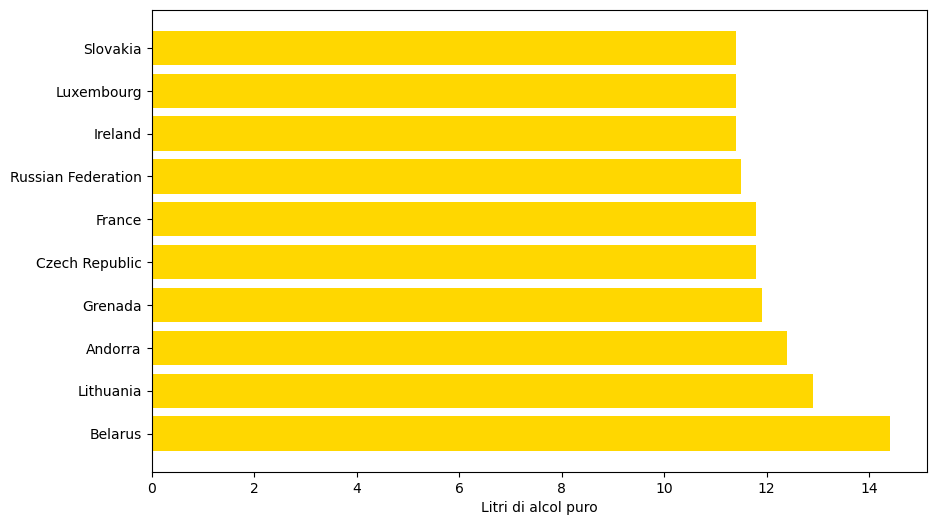

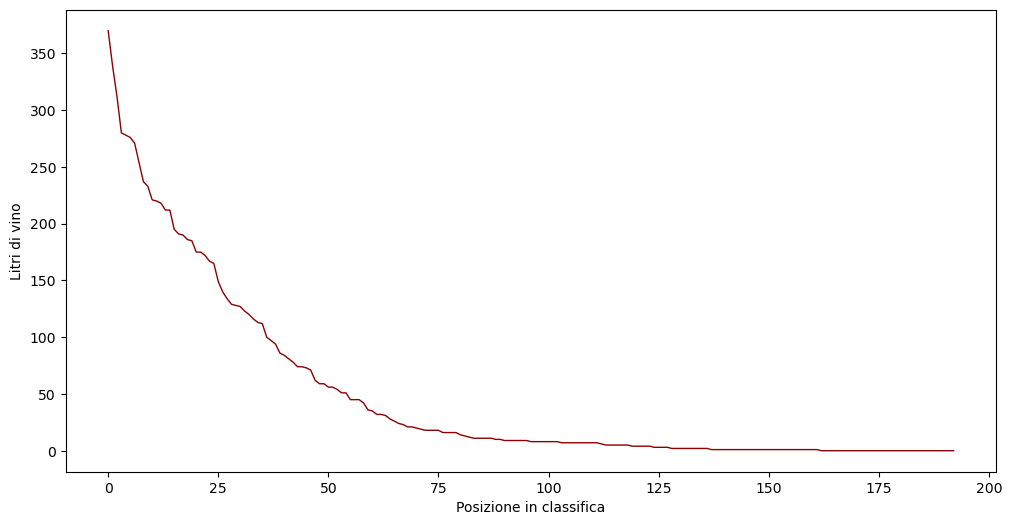

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

#1
top10_paesi = df.nlargest(10, 'total_litres_of_pure_alcohol')[['country', 'total_litres_of_pure_alcohol']]
print(top10_paesi)

#2
media_birra = df['beer_servings'].mean()
media_vino = df['wine_servings'].mean() 
media_super = df['spirit_servings'].mean()
print(f"media birra: {media_birra},media vino: {media_vino} media superalcolici: {media_super}")

#3
df['indice_alcol'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3
alcol_massimo = df.loc[df['indice_alcol'].idxmax(), ['country', 'indice_alcol']]
print(f"paese con il valore massimo di alcohol_index: {alcol_massimo['country']}")

#4
birra = df[df['beer_servings'] > 100][['country', 'beer_servings']]
print(birra)

#5 
plt.figure(figsize=(10,6))
plt.barh(top10_paesi['country'], top10_paesi['total_litres_of_pure_alcohol'], color='gold')
plt.xlabel('Litri di alcol puro')
plt.show()


df_vino = df.sort_values('wine_servings', ascending=False).reset_index(drop=True) #messo per creare una linea nel grafico sennò dava alcuni problemi
plt.figure(figsize=(12,6))
plt.plot(df_vino['wine_servings'], color='darkred', linewidth=1)
plt.xlabel('Posizione in classifica')
plt.ylabel('Litri di vino')
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

c:\Users\flavi\miniconda3\envs\amb_python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\flavi\miniconda3\envs\amb_python\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\flavi\.cache\huggingface\hub\datasets--lukebarousse--data_jobs. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order t

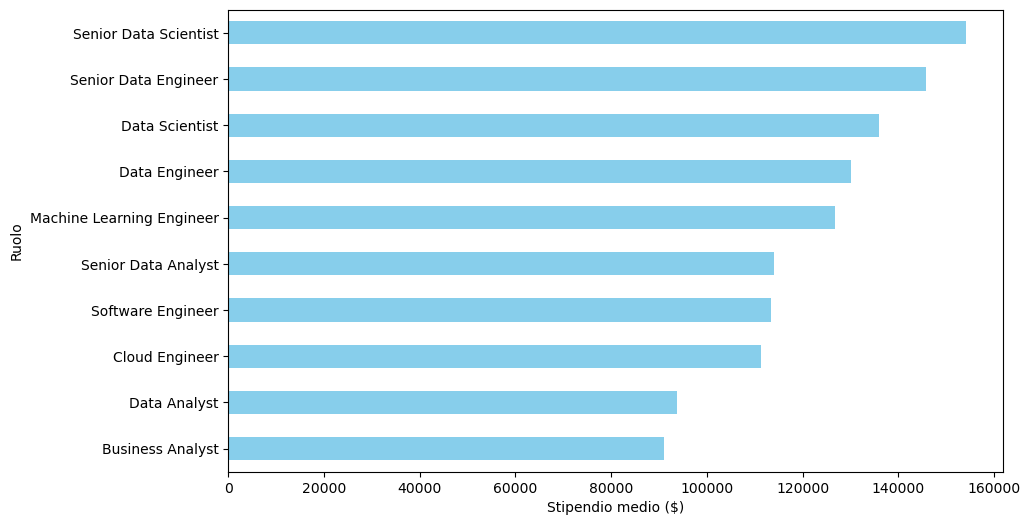

In [6]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

analisi_paesi = df.groupby('job_country')['salary_year_avg'].agg(['mean', 'count', 'min', 'max'])
stipendi_ruoli = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
stipendi_ruoli.plot(kind='barh', color='skyblue')
plt.xlabel('Stipendio medio ($)')
plt.ylabel('Ruolo')
plt.show()


### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()